In [29]:
!pip install scipy

In [30]:
import pandas as pd
import numpy as np

import scipy.stats as stats

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer


In [31]:
df = pd.read_csv('Titanic-Dataset.csv',usecols=['Age','Fare','Survived'])

In [32]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [33]:
df.isnull().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [34]:
df['Age'].fillna(df['Age'].mean())

0      22.000000
1      38.000000
2      26.000000
3      35.000000
4      35.000000
         ...    
886    27.000000
887    19.000000
888    29.699118
889    26.000000
890    32.000000
Name: Age, Length: 891, dtype: float64

In [35]:
df.isnull().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [36]:
df['Age'].fillna(df['Age'].mean(),inplace=True)

C:\Users\IRVINEi\AppData\Local\Temp\ipykernel_19960\694922604.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(),inplace=True)


In [37]:
df.isnull().sum()

Survived    0
Age         0
Fare        0
dtype: int64

In [38]:
X = df.iloc[:,1:3]
y = df.iloc[:,0]

In [39]:
X

,Age,Fare
0,22.000000,7.2500
1,38.000000,71.2833
2,26.000000,7.9250
3,35.000000,53.1000
4,35.000000,8.0500
...,...,...
886,27.000000,13.0000
887,19.000000,30.0000
888,29.699118,23.4500
889,26.000000,30.0000


In [40]:
y

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: Survived, Length: 891, dtype: int64

In [41]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

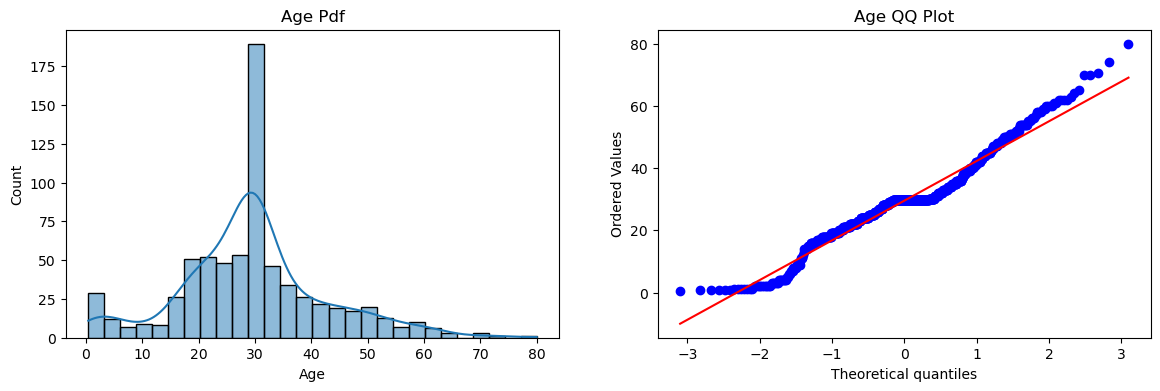

In [42]:
plt.figure(figsize=(14,4))

plt.subplot(121)
sns.histplot(X_train['Age'], kde=True)
plt.title('Age Pdf')

plt.subplot(122)
stats.probplot(X_train['Age'], dist='norm', plot=plt)
plt.title('Age QQ Plot')

plt.show()

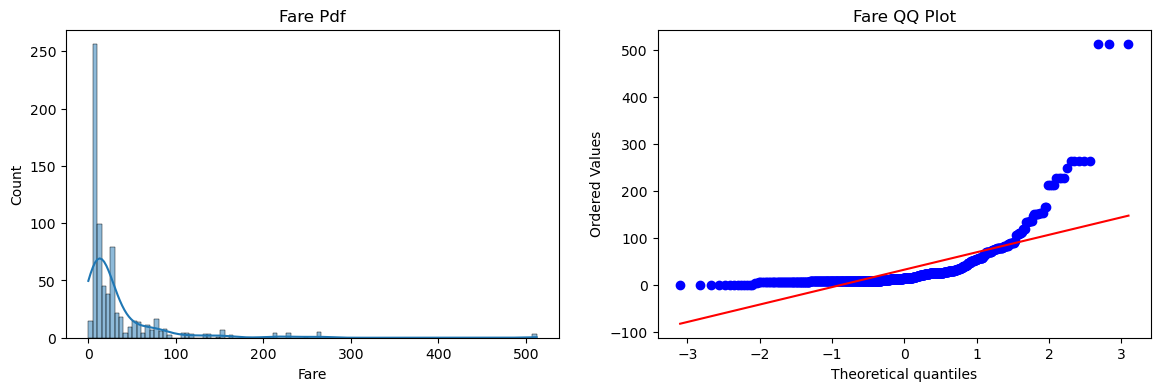

In [43]:
plt.figure(figsize=(14,4))

plt.subplot(121)
sns.histplot(X_train['Fare'], kde=True)
plt.title('Fare Pdf')

plt.subplot(122)
stats.probplot(X_train['Fare'], dist='norm', plot=plt)
plt.title('Fare QQ Plot')

plt.show()

In [44]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

In [45]:
clf.fit(X_train,y_train)
clf2.fit(X_train,y_train)

y_pred = clf.predict(X_test)
y_pred1 = clf2.predict(X_test)

print("accuracy LR", accuracy_score(y_test,y_pred))
print("accuracy DT", accuracy_score(y_test,y_pred1))



accuracy LR 0.6480446927374302
accuracy DT 0.659217877094972


In [46]:
trf = FunctionTransformer(func=np.log1p)

In [47]:
X_train_transformed = trf.fit_transform(X_train)
X_test_transformed = trf.transform(X_test)

In [60]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(X_train_transformed,y_train)
clf2.fit(X_train_transformed,y_train)

y_pred = clf.predict(X_test_transformed)
y_pred1 = clf2.predict(X_test_transformed)

print("accuracy LR", accuracy_score(y_test,y_pred))
print("accuracy DT", accuracy_score(y_test,y_pred1))

accuracy LR 0.6815642458100558
accuracy DT 0.6759776536312849


In [61]:
X_transformed = trf.fit_transform(X)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print('LR',np.mean(cross_val_score(clf,X_transformed,y,scoring='accuracy',cv=10)))
print('DT',np.mean(cross_val_score(clf2,X_transformed,y,scoring='accuracy',cv=10)))


LR 0.678027465667915
DT 0.6588139825218478


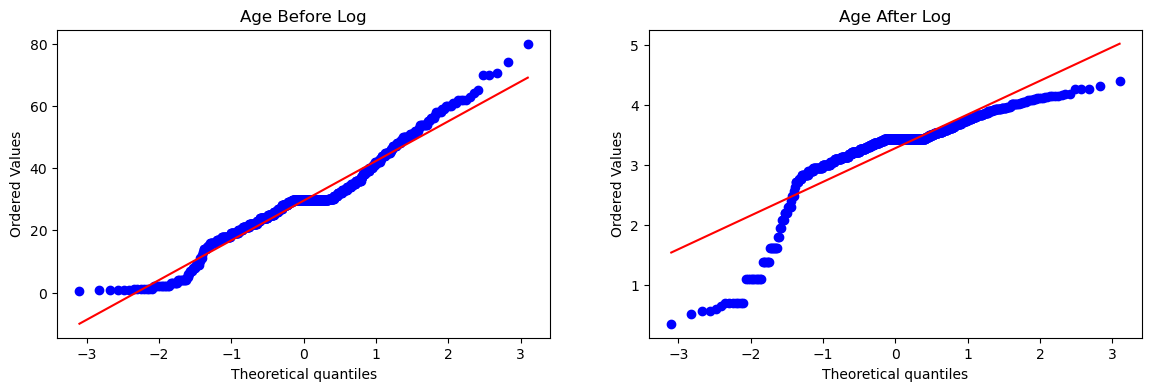

In [62]:
plt.figure(figsize=(14,4))

plt.subplot(121)
stats.probplot(X_train['Age'],dist='norm',plot=plt)
plt.title('Age Before Log')

plt.subplot(122)
stats.probplot(X_train_transformed['Age'],dist='norm',plot=plt)
plt.title("Age After Log")

plt.show()

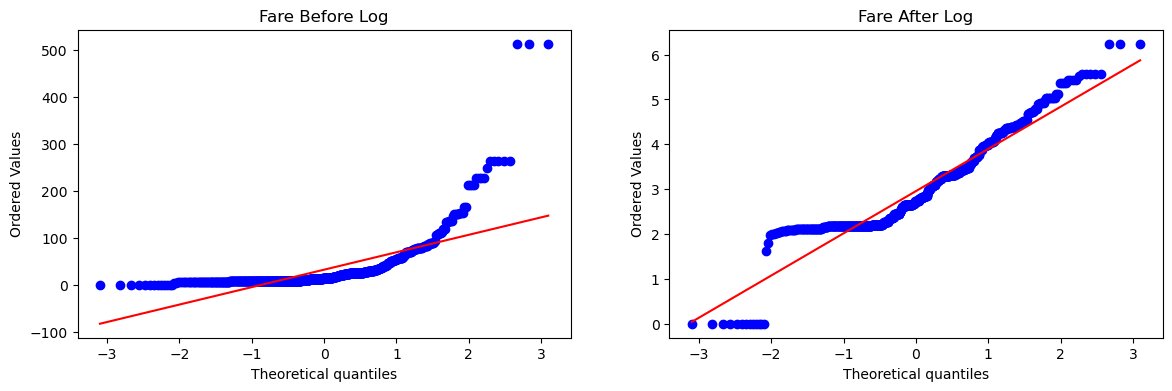

In [63]:
plt.figure(figsize=(14,4))

plt.subplot(121)
stats.probplot(X_train['Fare'],dist='norm',plot=plt)
plt.title('Fare Before Log')

plt.subplot(122)
stats.probplot(X_train_transformed['Fare'],dist='norm',plot=plt)
plt.title("Fare After Log")

plt.show()

In [64]:
trf2 = ColumnTransformer(
    transformers=[
        ('log', FunctionTransformer(np.log1p), ['Fare'])
    ],
    remainder='passthrough'
)

X_train_transformed2 = trf2.fit_transform(X_train)
X_test_transformed2 = trf2.transform(X_test)

In [65]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(X_train_transformed2,y_train)
clf2.fit(X_train_transformed2,y_train)

y_pred = clf.predict(X_test_transformed2)
y_pred1 = clf2.predict(X_test_transformed2)

print("Accuracy Score LR",accuracy_score(y_test,y_pred))
print("Accuracy Score DT",accuracy_score(y_test,y_pred1))


Accuracy Score LR 0.6703910614525139
Accuracy Score DT 0.6759776536312849


In [66]:
X_transformed2 = trf.fit_transform(X)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print('LR',np.mean(cross_val_score(clf,X_transformed2,y,scoring='accuracy',cv=10)))
print('DT',np.mean(cross_val_score(clf2,X_transformed2,y,scoring='accuracy',cv=10)))


LR 0.678027465667915
DT 0.6577153558052433


In [67]:
def apply_transfor(transform):
    X = df.iloc[:,1:3]
    y = df.iloc[:,0]

    trf = ColumnTransformer(
        [
            ('log',FunctionTransformer(transform),['Fare'])
        ],
        remainder='passthrough'
    )
    X_trans = trf.fit_transform(X)

    clf = LogisticRegression()

    print('Accuracy',np.mean(cross_val_score(clf,X_trans,y,scoring='accuracy',cv=10)))

    plt.figure(figsize=(14,4))

    plt.subplot(121)
    stats.probplot(X['Fare'],dist='norm',plot=plt)
    plt.title("Fare Before Transform")

    plt.subplot(122)
    stats.probplot(X_trans[:,0],dist='norm',plot=plt)
    plt.title("Fare After Transform")

    plt.show()

Accuracy 0.6589013732833957


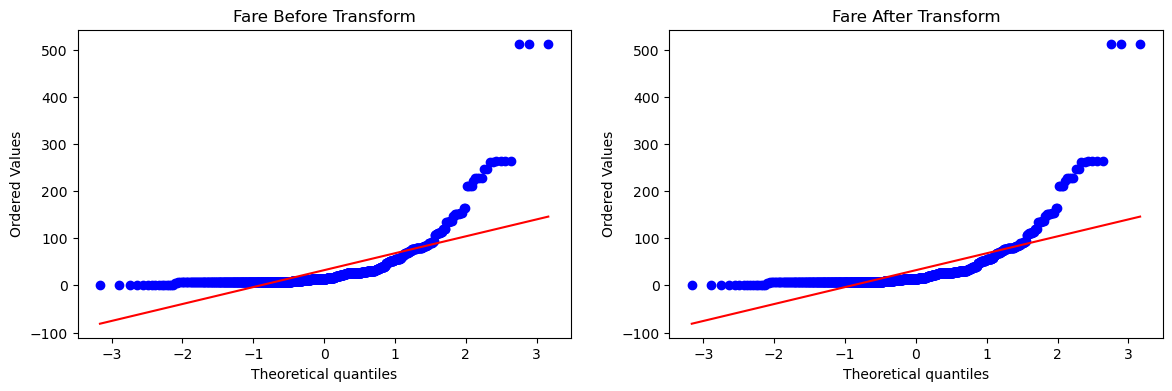

In [68]:
apply_transfor(lambda x:x)

Accuracy 0.6431335830212235


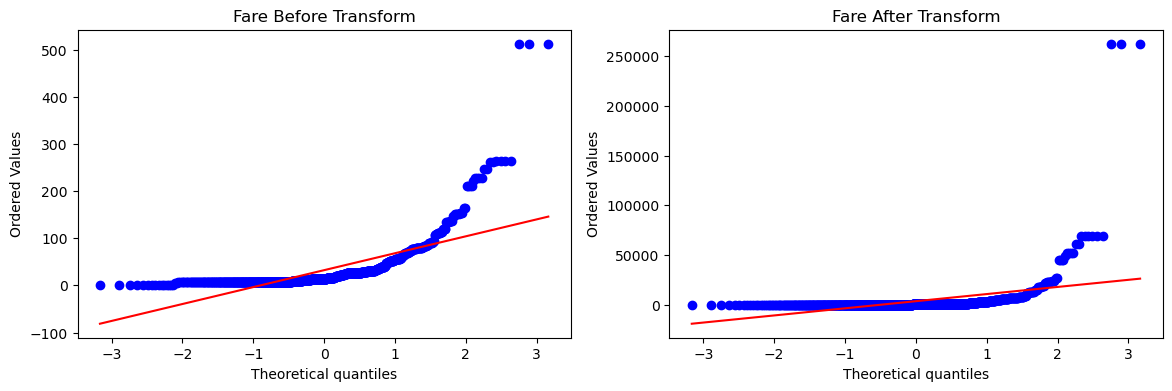

In [69]:
apply_transfor(lambda x:x**2)

Accuracy 0.6262796504369538


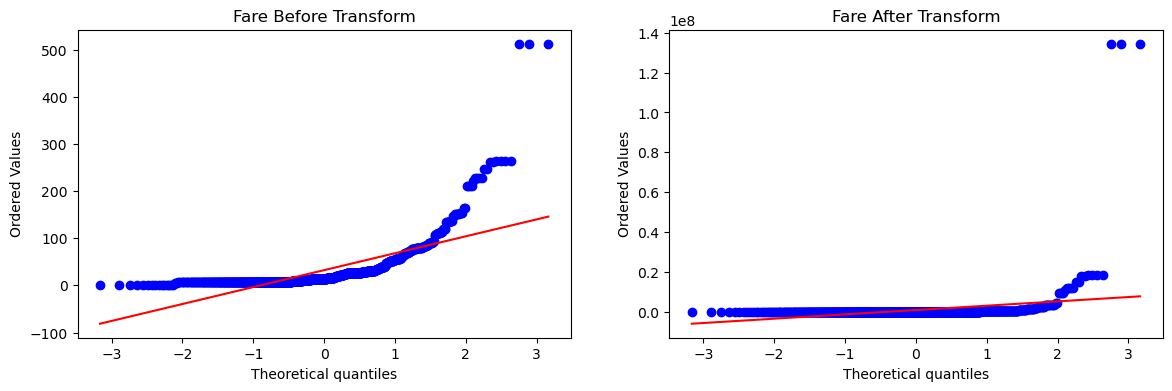

In [70]:
apply_transfor(lambda x:x**3)

Accuracy 0.6589013732833957


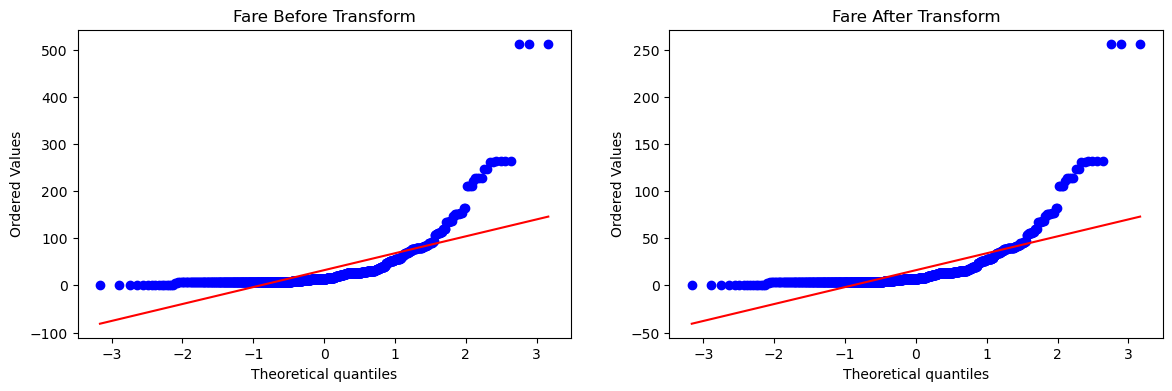

In [71]:
apply_transfor(lambda x:x**1/2)

Accuracy 0.61729088639201


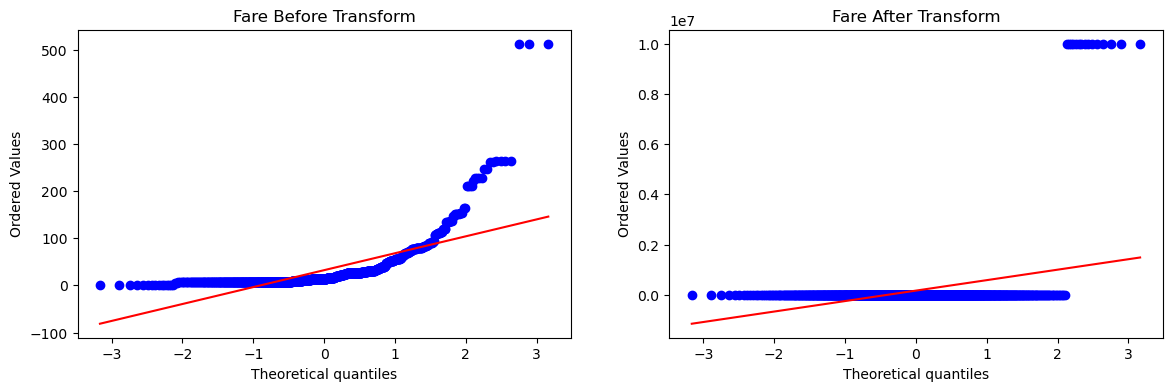

In [ ]:
apply_transfor(lambda x:1/(x+0.0000001))

Accuracy 0.61729088639201


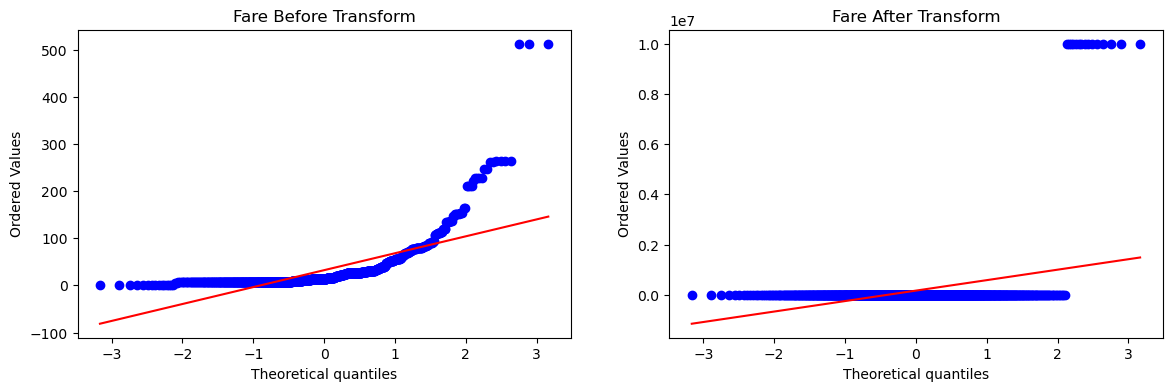

In [76]:
apply_transfor(lambda x:1/(x+0.0000001))

Accuracy 0.6712609238451936


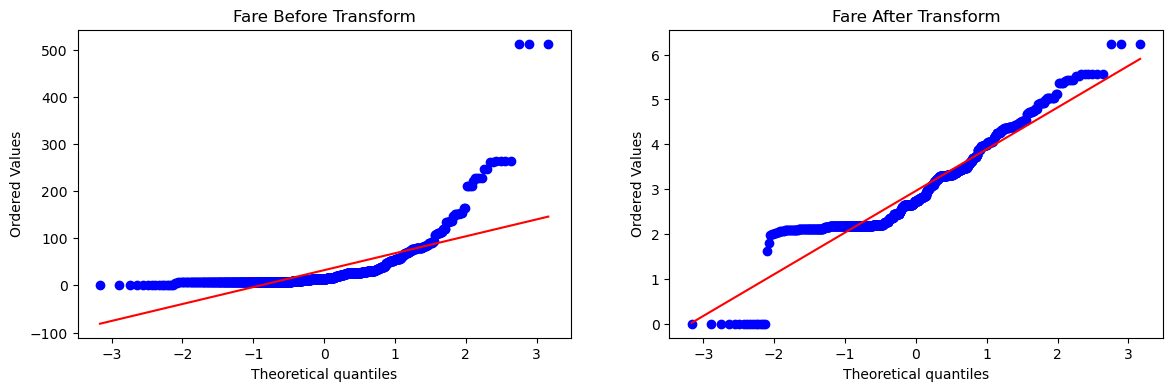

In [78]:
apply_transfor(lambda x:np.log(1+x))